In [3]:
# ================================
# TASK 3 - Semantic Image Retrieval
# ================================

In [4]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [5]:
import os
print(os.listdir("/content/drive/MyDrive/Alfaisal_Postdoc_Challenge"))


['Task1_CNN', 'Task2_Report_Generation', 'Task3_Image_Retrieval', 'best_model.pth']


In [6]:
import torch
import torchvision.models as models

# Redéfinir ResNet18
model = models.resnet18(pretrained=False)
model.fc = torch.nn.Linear(512, 2)

# Charger les poids
model.load_state_dict(
    torch.load("/content/drive/MyDrive/Alfaisal_Postdoc_Challenge/best_model.pth",
               map_location=torch.device('cpu'))
)

model.eval()

print("Model loaded successfully.")


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Model loaded successfully.


In [7]:
feature_extractor = torch.nn.Sequential(*list(model.children())[:-1])


In [8]:
import torch.nn.functional as F

# Enlever la dernière couche (fc)
feature_extractor = torch.nn.Sequential(*list(model.children())[:-1])
feature_extractor.eval()

print("Feature extractor ready.")


Feature extractor ready.


In [9]:
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader


In [10]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])


In [11]:
import os

print(os.listdir("/content/drive/MyDrive"))


['Classroom', 'DOC', 'plag-check-report-2025-01-22T07_59_34.pdf', 'AIP_Conference_Proceedings_License_Agreement_Biophtec 1.pdf', 'diplome (2).pdf', 'diplome (1).pdf', 'diplome.pdf', 'cv selmi kaouther (4).pdf', 'السيرة الذاتية.pdf', 'السيرة الذاتية )عربي و انقليزي) (1).pdf', 'السيرة الذاتية )عربي و انقليزي).pdf', 'cv selmi kaouther (4).docx', 'السيرة الذاتية )عربي).pdf', 'خطاب_تقديمي_جامعة_ليوا.pdf', 'Colab Notebooks', 'Alfaisal_Postdoc_Challenge']


In [12]:
print(os.listdir("/content/drive/MyDrive/Alfaisal_Postdoc_Challenge"))


['Task1_CNN', 'Task2_Report_Generation', 'Task3_Image_Retrieval', 'best_model.pth']


In [13]:
print(os.listdir("/content/drive/MyDrive/Alfaisal_Postdoc_Challenge/Task1_CNN"))


['Model loaded successfully.ipynb', 'Task1_CNN_PneumoniaMNIST.ipynb']


In [14]:
!pip install medmnist


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 6.3 MB/s eta 0:00:00


In [15]:
import medmnist
from medmnist import PneumoniaMNIST
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),  #  IMPORTANT
    transforms.ToTensor()
])


test_dataset = PneumoniaMNIST(
    split='test',
    transform=transform,
    download=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)


100%|██████████| 4.17M/4.17M [00:00<00:00, 25.3MB/s]


In [16]:
all_features = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:

        features = feature_extractor(images)
        features = features.view(features.size(0), -1)
        features = F.normalize(features, p=2, dim=1)

        all_features.append(features.cpu())
        all_labels.extend(labels.numpy())

all_features = torch.cat(all_features).numpy()

print("Embeddings shape:", all_features.shape)


Embeddings shape: (624, 512)


In [17]:
!pip install faiss-cpu


In [18]:
import faiss
import numpy as np

dimension = 512

index = faiss.IndexFlatIP(dimension)  # Inner Product (car on a normalisé)

index.add(all_features.astype(np.float32))

print("Number of indexed images:", index.ntotal)


Number of indexed images: 624


In [19]:
k = 5

query_vector = all_features[0].astype(np.float32).reshape(1, -1)

distances, indices = index.search(query_vector, k)

print("Indices:", indices)
print("Distances:", distances)


Indices: [[  0 167 245 335 277]]
Distances: [[1.         0.9994602  0.9993867  0.99936086 0.99921644]]


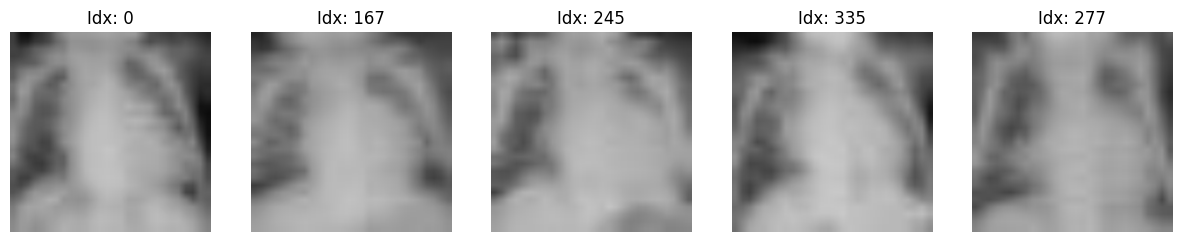

In [20]:
import matplotlib.pyplot as plt

k = 5
query_index = 0

query_vector = all_features[query_index].astype(np.float32).reshape(1, -1)
distances, indices = index.search(query_vector, k)

plt.figure(figsize=(15,4))

for i, idx in enumerate(indices[0]):
    image, label = test_dataset[idx]

    plt.subplot(1, k, i+1)
    plt.imshow(image.permute(1,2,0))
    plt.title(f"Idx: {idx}")
    plt.axis("off")

plt.show()


In [21]:
query_label = all_labels[query_index]

retrieved_labels = [all_labels[idx] for idx in indices[0]]

print("Query label:", query_label)
print("Retrieved labels:", retrieved_labels)


Query label: [1]
Retrieved labels: [array([1]), array([1]), array([1]), array([1]), array([1])]


In [22]:
def precision_at_k(index, features, labels, k=5):
    correct = 0
    total = len(features)

    for i in range(total):
        query = features[i].astype(np.float32).reshape(1, -1)
        distances, indices = index.search(query, k)

        query_label = labels[i]
        retrieved_labels = [labels[idx] for idx in indices[0]]

        # compter combien ont le même label
        matches = sum([1 for lbl in retrieved_labels if (lbl == query_label).all()])

        correct += matches / k

    return correct / total


precision5 = precision_at_k(index, all_features, all_labels, k=5)
print("Precision@5:", precision5)


Precision@5: 0.9019230769230774
